### Requirements:
- Python 3.10 or later
- *Jupyter Notebook*
- *egglog*
- *graphviz*

In [ ]:
%pip install egglog graphviz

Before saturation:


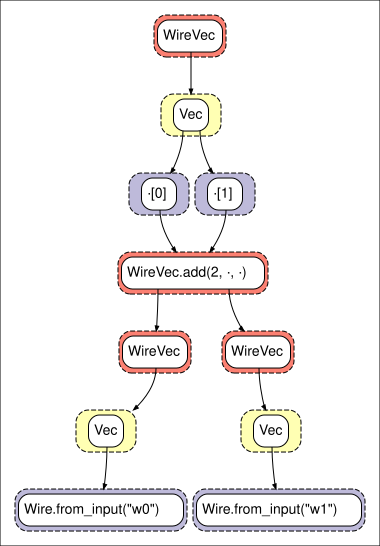

After saturation:


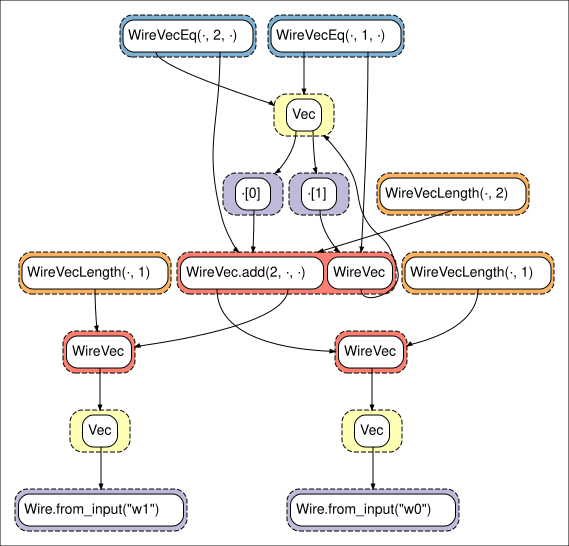

In [5]:
"""
WireVec Equivalence Example
"""

import emap
import egglog
from emap.core import Wire, WireVec

netlist = emap.Netlist()
wv0 = netlist.let("wv0", WireVec(egglog.Vec[Wire](Wire.from_input("w0"))))
wv1 = netlist.let("wv1", WireVec(egglog.Vec[Wire](Wire.from_input("w1"))))
wv2 = netlist.let("wv2", WireVec.add(2, wv0, wv1))
wv3 = netlist.let("wv3", WireVec(egglog.Vec[Wire](wv2[0], wv2[1])))
# wv2 == wv3

print("Before saturation:")
netlist.display(graphviz=True)

netlist.run(emap.misc_rules * 10)
netlist.check(egglog.eq(wv2).to(wv3))
print("After saturation:")
netlist.display(graphviz=True)

Netlist built in 0.01 seconds
Netlist saturated in 0.02 seconds


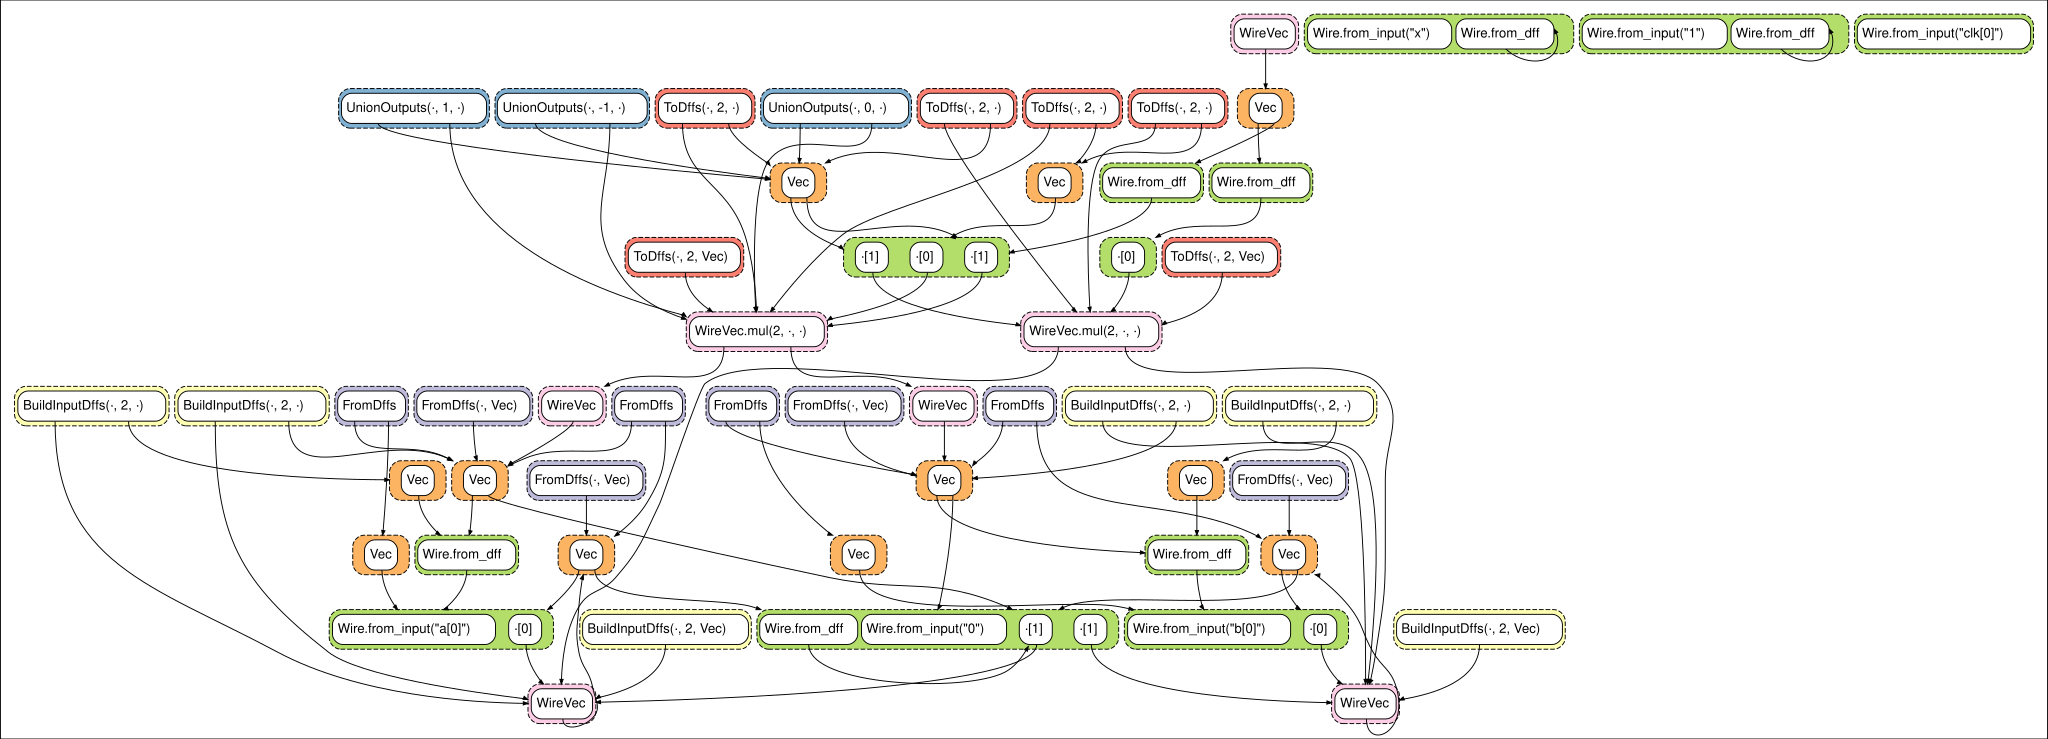

In [1]:
import emap
import json
import time

with open("good_multiplier_1bit.json", "r") as f:
    mod = json.load(f)["modules"]["top"]

netlist = emap.Netlist()

start_time = time.time()
netlist.build_from_json(mod, clk="clk")
print(f"Netlist built in {time.time() - start_time:.2f} seconds")

start_time = time.time()
report = netlist.run((emap.misc_rules + emap.retiming_rules) * 10)
print(f"Netlist saturated in {time.time() - start_time:.2f} seconds")

# for rule, count in report.num_matches_per_rule.items():
#     print(f"{rule}: {count} applications")

netlist.display(graphviz=True)
# for name, wv in netlist.outputs.items():
#     print(f"{name}: {wv}")